In [1]:
import pandas as pd
import plotly.express as px

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
#Valores vacíos en TotalCharges
datos_vacios = df[ df["TotalCharges"].str.strip() == "" ]
x = len(datos_vacios)
print(f"Hay {x} filas con datos vacios:")
display(datos_vacios)

Hay 11 filas con datos vacios:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
#Clientes con tenure 0, los mismos que tienen vacíos en TotalCharges
df [ df["tenure"] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
#Conversión de TotalCharges a float y vacios en NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

#Visualización de NaN
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
#Eliminación de NaN
df.dropna(subset = ['TotalCharges'], inplace = True)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### Guardado del dataset limpio

In [11]:
df.to_csv("customers.csv", index = False)

 ### Análisis Exploratorio de Datos (EDA)

### 1.Análisis de Churn (abandono de clientes)

In [12]:
df_conteo = df['Churn'].value_counts().reset_index()
df_conteo.columns = ['Churn', 'Total']

total_clientes = df_conteo["Total"].sum()
df_conteo["Porcentaje"] = (( df_conteo["Total"] / total_clientes ) * 100).round(2)
df_conteo["Etiqueta"] = df_conteo["Total"].astype(str) + "(" + df_conteo["Porcentaje"].astype(str) + "%)"
df_conteo

,Churn,Total,Porcentaje,Etiqueta
0,No,5163,73.42,5163(73.42%)
1,Yes,1869,26.58,1869(26.58%)


In [13]:
df_conteo = df['Churn'].value_counts().reset_index()
df_conteo.columns = ['Churn', 'Total']

total_clientes = df_conteo["Total"].sum()
df_conteo["Porcentaje"] = (( df_conteo["Total"] / total_clientes ) * 100).round(2)
df_conteo["Etiqueta"] = df_conteo["Total"].astype(str) + "(" + df_conteo["Porcentaje"].astype(str) + "%)"

fig1 = px.bar(df_conteo, 
             x="Churn", 
             y="Total",
             color="Churn",
             text="Etiqueta",
             title="<b>Tasa de abandono general de clientes del servicio: 26.58%<b>",
             template="plotly_white",
             color_discrete_map={"Yes":"#EF553B", "No":"#636EFA"},
             width = 1000,
             height = 500)

fig1.update_traces(textposition="outside")
fig1.update_yaxes(range = [0,6000])

display(fig1)

*Hallazgo: Aproximadamente 1 de cada 4 clientes abandona el servicio (tasa de abandono de 26.58%), esto representa una cantidad considerable (1869 clientes)*

### 2. Tipo de contrato como factor de riesgo de abandono

In [14]:
contrato_churn = df.groupby(["Contract", "Churn"]).size().reset_index(name="count")
contrato_total = df.groupby("Contract").size().reset_index(name = "total")
contrato_churn = contrato_churn.merge(contrato_total, on = "Contract")
contrato_churn["porcentaje"] = (contrato_churn["count"] / contrato_churn["total"] * 100).round(1).astype(str) + "%"
contrato_churn["etiqueta"] = contrato_churn["count"].astype(str) + "(" + contrato_churn["porcentaje"].astype(str) + ")"
contrato_churn

,Contract,Churn,count,total,porcentaje,etiqueta
0,Month-to-month,No,2220,3875,57.3%,2220(57.3%)
1,Month-to-month,Yes,1655,3875,42.7%,1655(42.7%)
2,One year,No,1306,1472,88.7%,1306(88.7%)
3,One year,Yes,166,1472,11.3%,166(11.3%)
4,Two year,No,1637,1685,97.2%,1637(97.2%)
5,Two year,Yes,48,1685,2.8%,48(2.8%)


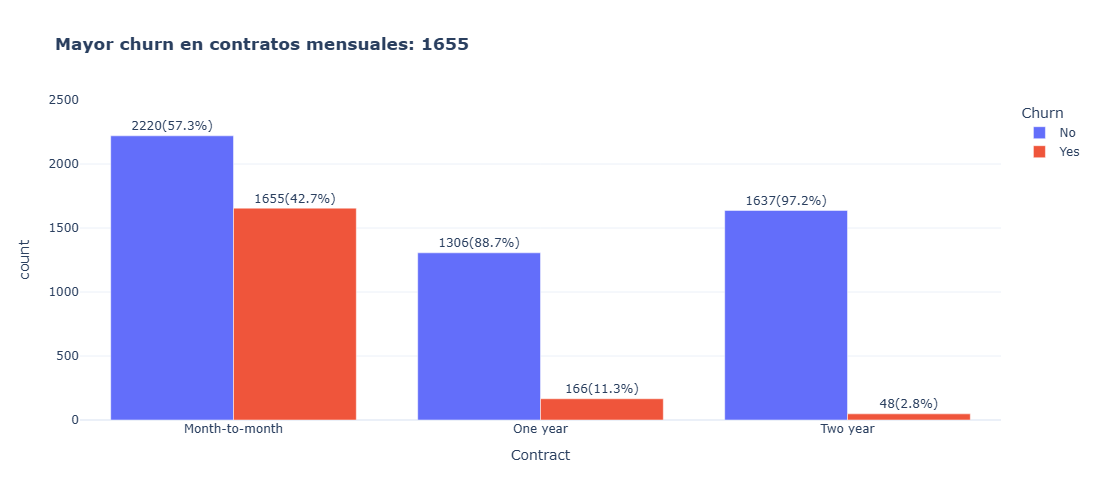

 * El churn de contratos mensuales representa el 88.55% del total de churn
 * El churn de contratos anuales representa el  8.88% del total de churn
 * El churn de contratos bianuales representa el 2.57% del total de churn


In [15]:
fig2_bar = px.bar(contrato_churn, 
             x="Contract", 
             y="count",
             color="Churn",
             text="etiqueta",
                  barmode = "group", 
             title="<b>Mayor churn en contratos mensuales: 1655<b>",
             template="plotly_white",
             color_discrete_map={"Yes":"#EF553B", "No":"#636EFA"},
                 width = 1000,
                 height = 500)

fig2_bar.update_traces(textposition="outside")
fig2_bar.update_yaxes(range = [0,2500])
 
display(fig2_bar)

#Calculamos porcentajes totales
churn_month_to_month = contrato_churn.loc[contrato_churn["Churn"] =="Yes"].iloc[0,2]
churn_one_year = contrato_churn.loc[contrato_churn["Churn"] == "Yes"].iloc[1,2]
churn_two_year = contrato_churn.loc[contrato_churn["Churn"] == "Yes"].iloc[2,2]

suma_churn_contrato = contrato_churn.loc[contrato_churn["Churn"] == "Yes"].iloc[:,2].sum()

porc_churn_month_to_month = ((churn_month_to_month / suma_churn_contrato) * 100).round(2)
porc_churn_one_year = ((churn_one_year / suma_churn_contrato) * 100).round(2)
porc_churn_two_year = ((churn_two_year / suma_churn_contrato) * 100).round(2)


print(f" * El churn de contratos mensuales representa el {porc_churn_month_to_month}% del total de churn")
print(f" * El churn de contratos anuales representa el  {porc_churn_one_year}% del total de churn")
print(f" * El churn de contratos bianuales representa el {porc_churn_two_year}% del total de churn")

*Insight: Lo mayor tasa de churn es en clientes con contratos mensuales, hay fuga de 1655 clientes (88.5% del total de churn). A diferencia de los churn de los contratos anuales y bianuales (166 y 48 respectivamente),el de lo contratos mensuales se posiciona con principal factor de riesgo. Para disminuir las tasas de abandono es recomendable incentivar la migración hacia contratos a largo plazo mediante descuentos o beneficios.*

### 3. Churn vs gasto mensual

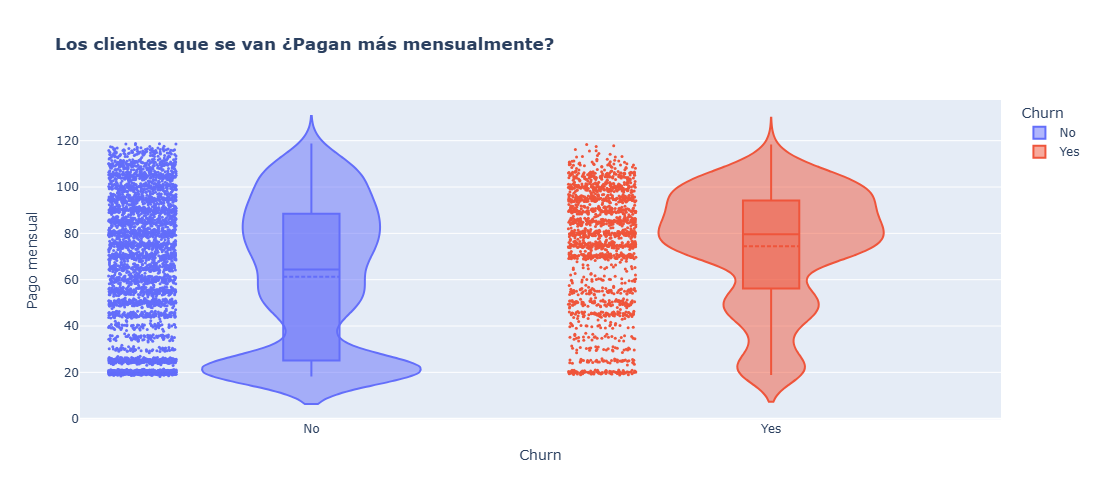

 * El promedio de pago mensual de clientes que abandonan el contrato: 74.44
 * El promedio de pago mensual de clientes que permanecen: 61.31


In [16]:
fig3_violin = px.violin(df,
                       x = "Churn",
                       y = "MonthlyCharges",
                       color = "Churn",
                       title="<b>Los clientes que se van ¿Pagan más mensualmente?<b>",
                        labels = {"MonthlyCharges":"Pago mensual"},
                        box = True,
                        points = "all",
                       width = 1000,
                       height = 500)
fig3_violin.update_traces(meanline_visible=True,
                         marker = dict(size =3) )

display(fig3_violin)

promedio_si = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean().round(2)
print(f" * El promedio de pago mensual de clientes que abandonan el contrato: {promedio_si}")

promedio_no = df[df['Churn'] == 'No']['MonthlyCharges'].mean().round(2)
print(f" * El promedio de pago mensual de clientes que permanecen: {promedio_no}")


*Insight: La mayor fuga de clientes se concentra en los que pagan 74.44 en promedio, a diferencia de los que se quedan: 61.31. Se observa que existe una correlación entre el precio y el abandono, parece ser que los clientes que contratan los servicios con paga mas alta no están recibiendo el valor suficiente o el precio es muy elevado.*

### 4. Churn vs tiempo (tenure)

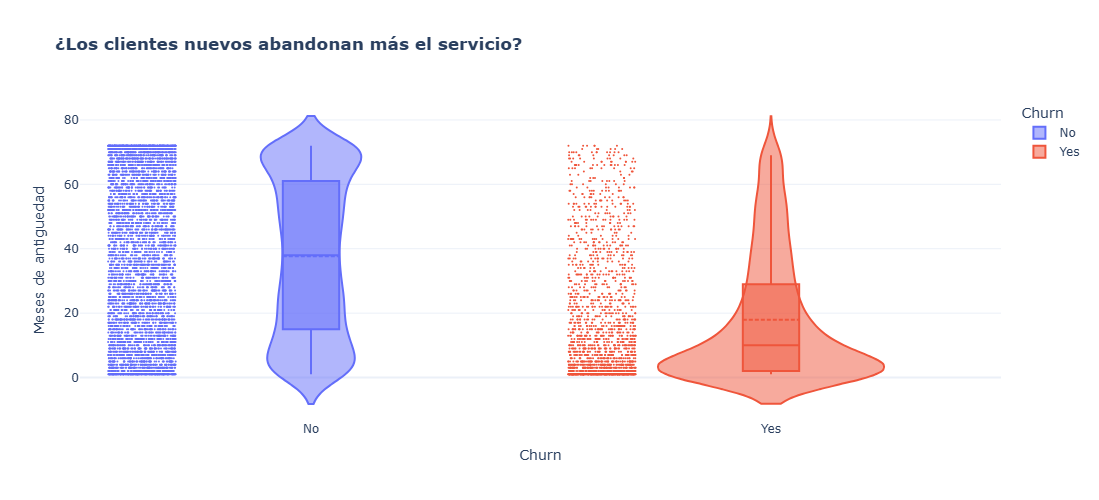

 * Promedio de antiguedad de clientes que abandonan el contrato:17.98 meses
 * Promedio de antiguedad de clientes que permanecen: 37.65 meses


In [17]:
fig4_violin = px.violin(df,
                       x = "Churn",
                       y = "tenure",
                       color = "Churn",
                       template="plotly_white",
                        points = "all",
                       box = True,
                       labels = {"tenure":"Meses de antiguedad"},
                       title = "<b>¿Los clientes nuevos abandonan más el servicio?<b>",
                       width = 1000,
                       height = 500)
fig4_violin.update_traces(meanline_visible = True, marker = dict(size = 2))
display(fig4_violin)

Promedio_tenure_si = df[df["Churn"] == "Yes"]["tenure"].mean().round(2)
Promedio_tenure_no = df[df["Churn"] == "No"]["tenure"].mean().round(2)
print(f" * Promedio de antiguedad de clientes que abandonan el contrato:{Promedio_tenure_si} meses")
print(f" * Promedio de antiguedad de clientes que permanecen: {Promedio_tenure_no} meses")

*Insight: En promedio, la antiguedad de clientes que abandonan el servicio es de 17.98 meses y de los que permanecen 37.65.Asimismo, hay una concentración de fuga de clientes con antigüedad de 10 meses a menos. La implementación de programas de Onboarding y seguimiento temprano podría reducir la tasa de churn.*

### 5. Churn vs tipo de servicio de internet

In [18]:
InternetService_churn = df.groupby(["InternetService", "Churn"]).size().reset_index(name="count")
InternetService_total = df.groupby("InternetService").size().reset_index(name = "conteo total")
InternetService_churn = InternetService_churn.merge(InternetService_total, on = "InternetService")
InternetService_churn["Porcentaje"] = ((InternetService_churn["count"] / InternetService_churn["conteo total"]) * 100).round(2)
InternetService_churn["etiqueta"] = InternetService_churn["count"].astype(str) + " (" + InternetService_churn["Porcentaje"].astype(str) + "%)"
InternetService_churn

,InternetService,Churn,count,conteo total,Porcentaje,etiqueta
0,DSL,No,1957,2416,81.00,1957 (81.0%)
1,DSL,Yes,459,2416,19.00,459 (19.0%)
2,Fiber optic,No,1799,3096,58.11,1799 (58.11%)
3,Fiber optic,Yes,1297,3096,41.89,1297 (41.89%)
4,No,No,1407,1520,92.57,1407 (92.57%)
5,No,Yes,113,1520,7.43,113 (7.43%)


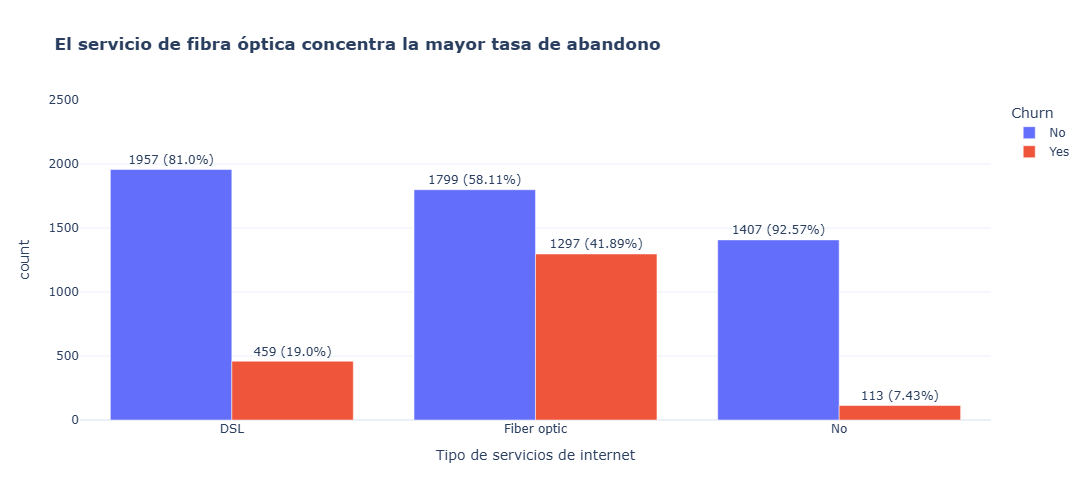

 * El churn de fibra óptica representa el 69.4% del total de churn
 * El churn de DSL representa el 24.56% del total de churn
 * El churn de clientes sin internet representa el 6.05% del total de churn


In [19]:
fig5_bar = px.bar(InternetService_churn, 
             x="InternetService", 
             y="count",
             color="Churn",
             text="etiqueta",
                  barmode = "group", 
             title="<b>El servicio de fibra óptica concentra la mayor tasa de abandono<b>",
                  labels = {"InternetService": "Tipo de servicios de internet"},
             template="plotly_white",
             color_discrete_map={"Yes":"#EF553B", "No":"#636EFA"},
                 width = 1000,
                 height = 500)

fig5_bar.update_traces(textposition="outside")
fig5_bar.update_yaxes(range = [0,2500])

display(fig5_bar)

#Porcentaje de churn de fibra optica y DSL
Chur_fibra_optica = InternetService_churn.loc[InternetService_churn["InternetService"] == "Fiber optic", "count"].iloc[1]
Churn_DSL = InternetService_churn.loc[InternetService_churn["InternetService"] == "DSL", "count"].iloc[1]
Churn_sin_servicio_internet = InternetService_churn.loc[InternetService_churn["InternetService"] == "No", "count"].iloc[1]

suma_churn_Yes = InternetService_churn.loc[InternetService_churn["Churn"] == "Yes"].iloc[:,2].sum()

porc_Chur_fibra_optica = ((Chur_fibra_optica / suma_churn_Yes) * 100).round(2)
porc_Churn_DSL = ((Churn_DSL / suma_churn_Yes) * 100).round(2)
porc_Churn_No = ((Churn_sin_servicio_internet / suma_churn_Yes) * 100).round(2)

print(f" * El churn de fibra óptica representa el {porc_Chur_fibra_optica}% del total de churn")
print(f" * El churn de DSL representa el {porc_Churn_DSL}% del total de churn")
print(f" * El churn de clientes sin internet representa el {porc_Churn_No}% del total de churn")

*Insight: El servicio de fibra optica tiene un porcentaje de churn de 41.89% el cual representa el 69.4% de churn total, en contraste con clientes con servicio de internet DSL y los que no tienen: 24.56% y 6.05% de churn total repectivamente. La información percibida sugiere que el problema de abandono de clientes se concentra en la propuesta de valor del servicio de fibra optica, se recomienda revisar la calidad, precio y velocidad de este tipo de servicio.*

### Conclusión FINAL

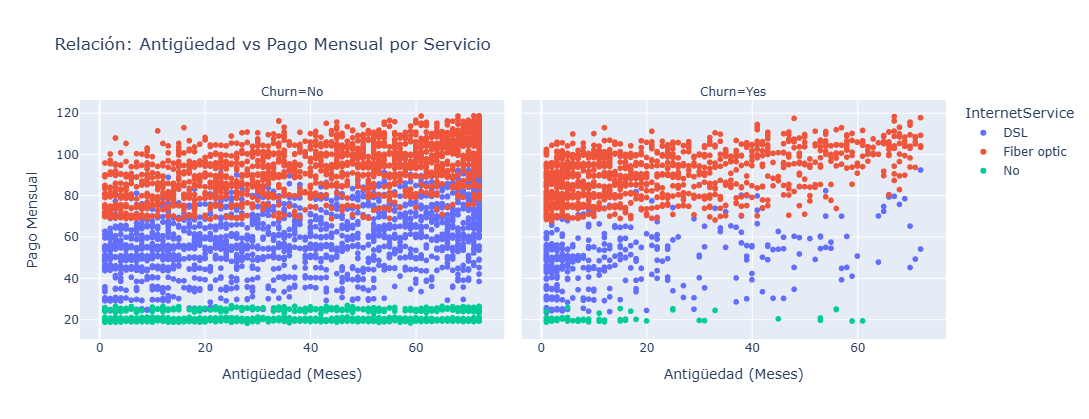

In [20]:
fig_final_dispersion = px.scatter(df, 
                            x="tenure", 
                            y="MonthlyCharges", 
                            color="InternetService", 
                            facet_col="Churn",
                            title="Relación: Antigüedad vs Pago Mensual por Servicio",
                            labels={"tenure": "Antigüedad (Meses)", "MonthlyCharges": "Pago Mensual"},
                                 width = 1100,
                                 height = 400)
fig_final_dispersion.show()

*Conclusión Final: Mediante un analisis multidimensional (Tenure, Internet service y Monthly Charges) se observó  una mayor concentración de churn en clientes con pagos elevados (rango de 80 a 100), servicios de fibra óptica y una antiguedad temprana de clientes (0 a 10 meses). Teniendo en cuenta ello se recomienda revisar el servicio de internet fibra optica, mejorar la calidad, realizar onboarding y seguimiento de clientes, asi como evaluar el costo ya que los clientes parecen no estar satisfechos con el beneficio-costo percibido.*